In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
OUR_RESULT_CSV = "../../out/table/results.csv"
EDPC_RESULT_CSV = "../../out/table/EDPC_results.csv"

In [3]:
pd.options.display.float_format = "{:.3f}".format
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 14,
    }
)

In [4]:
def get_number_of_instructions(circuit_name: str) -> int:
    with open(f"../../data/circuit/{circuit_name}.in") as f:
        lines = f.readlines()
    return sum(bool(line) for line in lines)

In [5]:
def load_edpc(csv_name):
    df = pd.read_csv(csv_name)
    df["factory"] = "outer"
    df["layer_count"] = 1
    df["allocator"] = "naive"
    df["msf_coeff"] = 0
    df["msf_prep_time"] = 0
    df["routing_algo"] = "EDPC"
    df["routing_option"] = "Yes_Kink"
    return df


def modify(df):
    instruction_count = {
        c: get_number_of_instructions(c) for c in df["circuit"].unique()
    }
    df["instruction_count"] = df["circuit"].map(instruction_count)
    df["cbpi"] = df["total_code_beat"] / df["instruction_count"]
    df["architecture"] = (
        df["layer_count"].map({1: "2D", 2: "2.5D"}) + " " + df["factory"]
    )
    df["allocator_msf"] = df["allocator"] + " " + df["msf_coeff"].astype(str)

    # As the Single 2D results assumes that paths take 2 code beat,
    # the cost should be doubled.
    # Also, the `yes_kink` cost should be the `no_kink` cost.
    mask = (df["routing_algo"] == "Single") & (df["layer_count"] == 1)
    metrics_cols = ["total_code_beat", "circuit_volume", "cbpi"]
    df.loc[mask, metrics_cols] *= 2

    df_single_2d = df[mask]
    df_single_2d_yes_kink = df_single_2d[
        df_single_2d["routing_option"] == "No_Kink"
    ].copy()
    df_single_2d_yes_kink["routing_option"] = "Yes_Kink"

    df = pd.concat((df, df_single_2d_yes_kink)).reset_index(drop=True)
    return df

In [6]:
def extract_best_sa(df):
    idx = df.groupby(
        [
            "circuit",
            "factory",
            "layer_count",
            "allocator",
            "routing_algo",
            "routing_option",
            "msf_prep_time",
        ]
    )["total_code_beat"].idxmin()
    return df.loc[idx]

In [7]:
order_info = {
    "architecture": ["2D outer", "2D inner", "2.5D outer", "2.5D inner"],
    "allocator": ["naive", "random", "SA"],
    "routing_algo": ["Single", "Double", "Proj"],
}

In [8]:
df_ours = modify(pd.read_csv(OUR_RESULT_CSV))
df_ours_best_sa = extract_best_sa(df_ours)
df_edpc = modify(load_edpc(EDPC_RESULT_CSV))

# 3. Architectures

## MSF Preparation Time Comparison

### Cat Plot

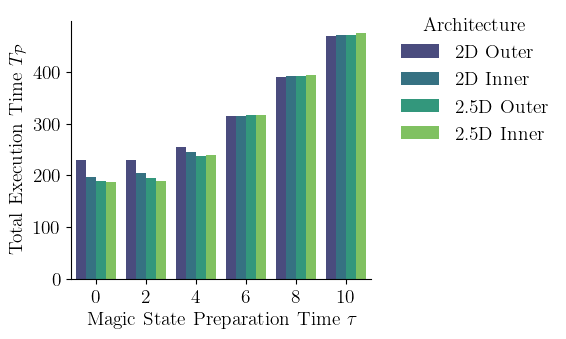

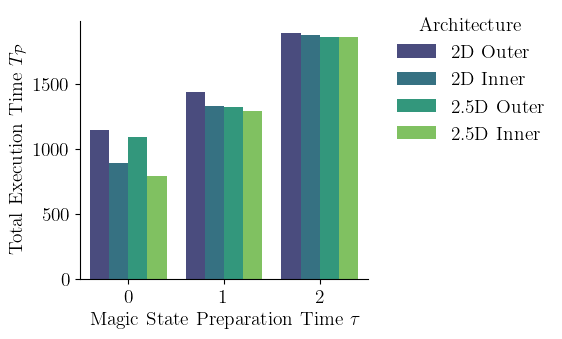

In [9]:
def change_msf_plot(df, circuit):
    df["Architecture"] = df["architecture"].map(
        {
            "2D outer": "2D Outer",
            "2D inner": "2D Inner",
            "2.5D outer": "2.5D Outer",
            "2.5D inner": "2.5D Inner",
        }
    )
    g = sns.catplot(
        data=df,
        x="msf_prep_time",
        y="total_code_beat",
        kind="bar",
        hue="Architecture",
        hue_order=["2D Outer", "2D Inner", "2.5D Outer", "2.5D Inner"],
        palette="viridis",
        height=3.5,
        aspect=1.2,
    )
    g.set_axis_labels(
        r"Magic State Preparation Time $\tau$",
        r"Total Execution Time $T_{\mathcal{P}}$",
    )
    sns.move_legend(g, "upper left", bbox_to_anchor=(0.73, 1.0))
    sns.despine()
    plt.savefig(f"../../fig/{circuit}_change_msf.pdf", bbox_inches="tight")
    plt.show()


df_double = df_ours_best_sa[
    (df_ours_best_sa["routing_algo"] == "Double")
    & (df_ours_best_sa["routing_option"] == "Yes_Kink")
    & (df_ours_best_sa["allocator"] == "SA")
]
for circuit, df_circuit in sorted(df_double.groupby("circuit")):
    if "Heisenberg2D" in str(circuit) and str(circuit).endswith("6"):
        change_msf_plot(df_circuit, circuit)
    if "trotter" in str(circuit) and "det" in str(circuit):
        change_msf_plot(df_circuit, circuit)

## General Performance Trend

### Double Yes Kink SA SELECT random local 6

2D vs. 2.5D で顕著な例

,circuit,factory,layer_count,allocator,msf_coeff,msf_prep_time,routing_algo,routing_option,total_code_beat,circuit_volume,instruction_count,cbpi,architecture,allocator_msf,Factory Layout,Qubit Layout
7953,result_SELECT_100_random_local_OBC_0_0_6,inner,1,SA,0.010,2,Double,Yes_Kink,414,829435,15764,0.026,2D inner,SA 0.01,Inner,2D
999,result_SELECT_100_random_local_OBC_0_0_6,inner,2,SA,0.100,2,Double,Yes_Kink,283,572243,15764,0.018,2.5D inner,SA 0.1,Inner,2.5D
6641,result_SELECT_100_random_local_OBC_0_0_6,outer,1,SA,0.001,2,Double,Yes_Kink,424,864899,15764,0.027,2D outer,SA 0.001,Outer,2D
3411,result_SELECT_100_random_local_OBC_0_0_6,outer,2,SA,0.100,2,Double,Yes_Kink,297,616058,15764,0.019,2.5D outer,SA 0.1,Outer,2.5D


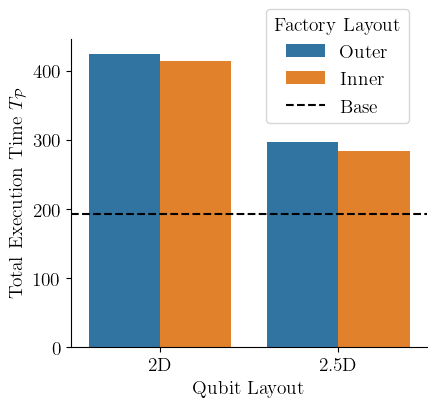

In [10]:
order_info_sa = order_info.copy()
order_info_sa["allocator"] = ["SA"]

for circuit, df_circuit in sorted(df_ours_best_sa.groupby("circuit")):
    if (
        "SELECT" in str(circuit)
        and "random" in str(circuit)
        and str(circuit).endswith("6")
    ):
        df_data = df_circuit[
            (df_circuit["allocator"] == "SA") & (df_circuit["routing_algo"] == "Double")
        ]
        df_bar = df_data[df_data["routing_option"] == "Yes_Kink"].copy()
        df_base = df_data[df_data["routing_option"] == "No_MSF"]
        df_bar["Factory Layout"] = df_bar["factory"].map(
            {"outer": "Outer", "inner": "Inner"}
        )
        df_bar["Qubit Layout"] = df_bar["layer_count"].map({1: "2D", 2: "2.5D"})
        display(df_bar)
        fig, ax = plt.subplots(figsize=(4.6, 4))
        g = sns.barplot(
            data=df_bar,
            x="Qubit Layout",
            y="total_code_beat",
            hue="Factory Layout",
            hue_order=["Outer", "Inner"],
            # palette="viridis",
            ax=ax,
        )
        base = df_base["total_code_beat"].iloc[0]
        plt.axhline(base, color="k", linestyle="dashed", label="Base")
        # print(circuit)

        ax.set_ylabel(r"Total Execution Time $T_{\mathcal{P}}$")

        handles, labels = ax.get_legend_handles_labels()
        # 不要な凡例タイトルを削除し、図(figure)レベルで凡例を再生成
        ax.get_legend().remove()
        fig.legend(
            handles,
            labels,
            loc="upper right",
            bbox_to_anchor=(0.88, 0.98),
            title="Factory Layout",
        )

        # sns.move_legend(g, "upper left", bbox_to_anchor=(1.01, 1.0))
        sns.despine(ax=ax)
        plt.savefig(f"../../fig/{circuit}_compare_dim.pdf", bbox_inches="tight")
        plt.show()
        # circuit_stack_plot(
        #     circuit,
        #     df_circuit,
        #     col="routing_algo",
        #     row="allocator",
        #     x="architecture",
        #     order_info=order_info_sa,
        # )

## Routing Comparison

### Routing + Mapping でプロット

  Routing / Mapping  cbpi
0      EDPC / naive 0.006
1    Single / naive 0.006
2    Double / naive 0.006
3     Proj. / naive 0.006
4       Single / SA 0.006
5       Double / SA 0.006
6        Proj. / SA 0.006
  Routing / Mapping  circuit_volume_scaled
0      EDPC / naive                  0.148
1    Single / naive                  0.148
2    Double / naive                  0.148
3     Proj. / naive                  0.148
4       Single / SA                  0.148
5       Double / SA                  0.148
6        Proj. / SA                  0.148


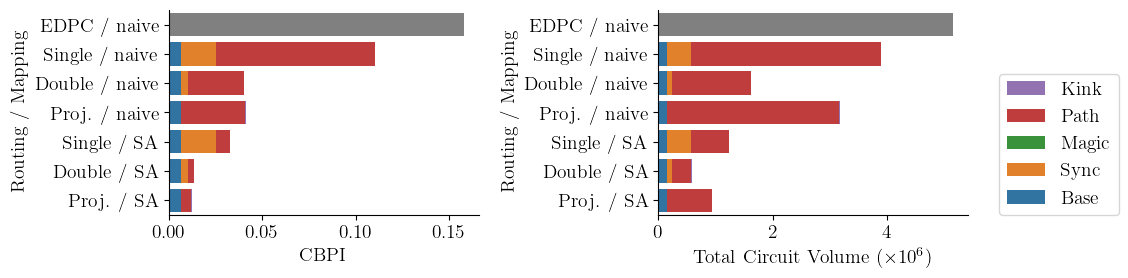

In [11]:
option_styles = {
    "No_MSF": {"label": "Sync", "color": "C1"},
    "No_Top": {"label": "Magic", "color": "C2"},
    "No_Kink": {"label": "Path", "color": "C3"},
    "Yes_Kink": {"label": "Kink", "color": "C4"},
}

delim = r" / "

routing_allocators = [
    f"EDPC{delim}naive",
    f"Single{delim}naive",
    f"Double{delim}naive",
    f"Proj.{delim}naive",
    f"Single{delim}SA",
    f"Double{delim}SA",
    f"Proj.{delim}SA",
]

df_merged = pd.concat((df_ours_best_sa, df_edpc))
df_merged[f"Routing{delim}Mapping"] = (
    df_merged["routing_algo"].map(lambda f: (f + "." if f == "Proj" else f))
    + delim
    + df_merged["allocator"]
)

df_arc = df_merged[
    (df_merged["factory"] == "outer")
    & (df_merged["layer_count"] == 1)
    & (df_merged["msf_prep_time"] == 0)
].copy()
df_arc["circuit_volume_scaled"] = df_arc["circuit_volume"] / 1e6

for circuit, df_circuit in sorted(df_arc.groupby("circuit")):
    if "SELECT" in str(circuit) and str(circuit).endswith("6"):
        fig, axes = plt.subplots(1, 2, figsize=(10, 3))
        for ax, metric, xlabel in zip(
            axes,
            ["cbpi", "circuit_volume_scaled"],
            ["CBPI", r"Total Circuit Volume ($\times10^6$)"],
        ):
            stack_height = []
            for routing_option, style in reversed(option_styles.items()):
                sns.barplot(
                    data=df_circuit[df_circuit["routing_option"] == routing_option],
                    x=metric,
                    y=f"Routing{delim}Mapping",
                    ax=ax,
                    order=routing_allocators,
                    **style,
                )
            base = df_circuit[
                (df_circuit["routing_algo"] == "Proj")
                & (df_circuit["routing_option"] == "No_MSF")
            ][metric].iloc[0]

            df_base = pd.DataFrame(
                {
                    f"Routing{delim}Mapping": routing_allocators,
                    metric: [base] * len(routing_allocators),
                }
            )
            print(df_base)
            sns.barplot(
                data=df_base,
                x=metric,
                y=f"Routing{delim}Mapping",
                ax=ax,
                order=routing_allocators,
                color="C0",
                label="Base",
            )
            sns.barplot(
                data=df_circuit,
                x=metric,
                y=f"Routing{delim}Mapping",
                ax=ax,
                order=[routing_allocators[0]],
                color="gray",
            )
            ax.set_xlabel(xlabel)
            sns.despine(ax=ax)
        # plt.savefig(f"../../fig/{circuit}_compare_dim.pdf", bbox_inches="tight")

        axes[0].get_legend().remove()
        handles, labels = axes[1].get_legend_handles_labels()
        axes[1].get_legend().remove()
        fig.legend(
            handles,
            labels,
            loc="upper left",
            bbox_to_anchor=(1, 0.75),
        )

        plt.tight_layout()
        plt.savefig("../../fig/compare_routing_and_allocator.pdf", bbox_inches="tight")
        plt.show()

  Routing / Mapping / Dimension  cbpi
0             EDPC / naive / 2D 0.006
1           Single / naive / 2D 0.006
2           Double / naive / 2D 0.006
3            Proj. / naive / 2D 0.006
4              Single / SA / 2D 0.006
5              Double / SA / 2D 0.006
6               Proj. / SA / 2D 0.006
7            Single / SA / 2.5D 0.006
8            Double / SA / 2.5D 0.006
9             Proj. / SA / 2.5D 0.006
  Routing / Mapping / Dimension  circuit_volume_scaled
0             EDPC / naive / 2D                  0.148
1           Single / naive / 2D                  0.148
2           Double / naive / 2D                  0.148
3            Proj. / naive / 2D                  0.148
4              Single / SA / 2D                  0.148
5              Double / SA / 2D                  0.148
6               Proj. / SA / 2D                  0.148
7            Single / SA / 2.5D                  0.148
8            Double / SA / 2.5D                  0.148
9             Proj. / SA / 2.5D 

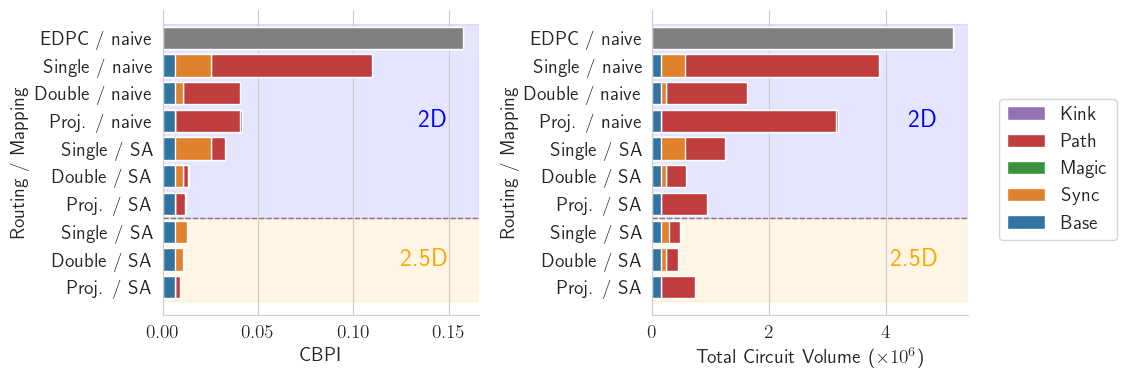

In [12]:
# 2.5D も追加した version

option_styles = {
    "No_MSF": {"label": "Sync", "color": "C1"},
    "No_Top": {"label": "Magic", "color": "C2"},
    "No_Kink": {"label": "Path", "color": "C3"},
    "Yes_Kink": {"label": "Kink", "color": "C4"},
}

delim = r" / "

layer_count_repr_dict = {1: "2D", 2: "2.5D"}

x_column_name = f"Routing{delim}Mapping{delim}Dimension"

routing_allocator_dimensions = [
    f"EDPC{delim}naive{delim}2D",
    f"Single{delim}naive{delim}2D",
    f"Double{delim}naive{delim}2D",
    f"Proj.{delim}naive{delim}2D",
    f"Single{delim}SA{delim}2D",
    f"Double{delim}SA{delim}2D",
    f"Proj.{delim}SA{delim}2D",
    f"Single{delim}SA{delim}2.5D",
    f"Double{delim}SA{delim}2.5D",
    f"Proj.{delim}SA{delim}2.5D",
]

df_merged = pd.concat((df_ours_best_sa, df_edpc))

df_merged[x_column_name] = (
    df_merged["routing_algo"].map(lambda f: (f + "." if f == "Proj" else f))
    + delim
    + df_merged["allocator"]
    + delim
    + df_merged["layer_count"].map(layer_count_repr_dict)
)

df_arc = df_merged[
    (df_merged["factory"] == "outer") & (df_merged["msf_prep_time"] == 0)
].copy()
df_arc["circuit_volume_scaled"] = df_arc["circuit_volume"] / 1e6

for circuit, df_circuit in sorted(df_arc.groupby("circuit")):
    if "SELECT" in str(circuit) and str(circuit).endswith("6"):
        sns.set_style("whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        for ax, metric, xlabel in zip(
            axes,
            ["cbpi", "circuit_volume_scaled"],
            ["CBPI", r"Total Circuit Volume ($\times10^6$)"],
        ):
            stack_height = []
            for routing_option, style in reversed(option_styles.items()):
                sns.barplot(
                    data=df_circuit[df_circuit["routing_option"] == routing_option],
                    x=metric,
                    y=x_column_name,
                    ax=ax,
                    order=routing_allocator_dimensions,
                    **style,
                )
            base = df_circuit[
                (df_circuit["routing_algo"] == "Proj")
                & (df_circuit["routing_option"] == "No_MSF")
            ][metric].iloc[0]

            df_base = pd.DataFrame(
                {
                    x_column_name: routing_allocator_dimensions,
                    metric: [base] * len(routing_allocator_dimensions),
                }
            )
            print(df_base)
            sns.barplot(
                data=df_base,
                x=metric,
                y=x_column_name,
                ax=ax,
                order=routing_allocator_dimensions,
                color="C0",
                label="Base",
            )
            sns.barplot(
                data=df_circuit,
                x=metric,
                y=x_column_name,
                ax=ax,
                order=[routing_allocator_dimensions[0]],
                color="gray",
            )

            # y軸のラベルを短いものに置き換え（FixedLocatorで警告回避）
            ax.set_yticks(range(len(routing_allocator_dimensions)))
            ax.set_yticklabels(
                list(map(lambda s: s[0 : s.rfind(delim)], routing_allocator_dimensions))
            )
            ax.set_xlabel(xlabel)
            ax.set_ylabel(f"Routing{delim}Mapping")

            # 背景に2Dと2.5Dの注釈を追加
            xlim = ax.get_xlim()
            ylim = ax.get_ylim()
            y_line = 6.5
            ax.axhline(y=y_line, color="gray", linestyle="--", linewidth=1, zorder=0)
            ax.axhspan(-0.5, y_line, alpha=0.1, color="blue", zorder=0)
            ax.axhspan(y_line, 9.5, alpha=0.1, color="orange", zorder=0)

            # 2Dのテキスト
            for y, text_content, color in [(3, "2D", "blue"), (8, "2.5D", "orange")]:
                ax.text(
                    xlim[1] * 0.9,
                    y,
                    text_content,
                    ha="right",
                    va="center",
                    fontsize=18,
                    weight="bold",
                    color=color,
                )

            sns.despine(ax=ax)
        # plt.savefig(f"../../fig/{circuit}_compare_dim.pdf", bbox_inches="tight")

        axes[0].get_legend().remove()
        handles, labels = axes[1].get_legend_handles_labels()
        axes[1].get_legend().remove()
        fig.legend(
            handles,
            labels,
            loc="upper left",
            bbox_to_anchor=(1, 0.75),
        )

        plt.tight_layout()
        plt.savefig(
            "../../fig/compare_routing_and_allocator_and_dimension.pdf",
            bbox_inches="tight",
        )
        plt.show()

## CV-CB Plot

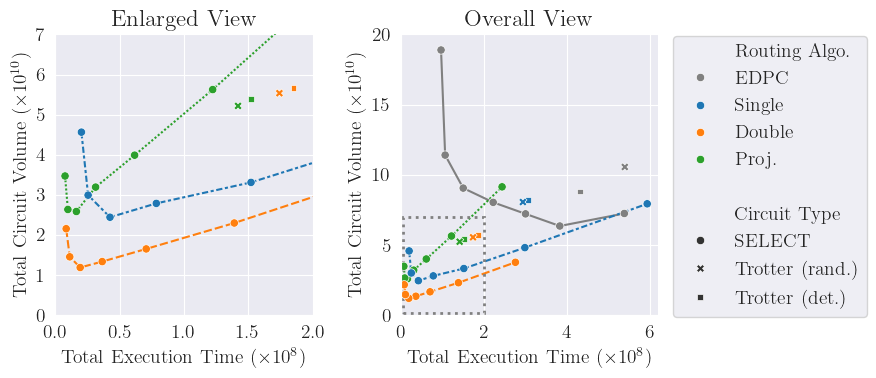

In [13]:
import matplotlib.patches as patches
from matplotlib.lines import Line2D

factory = "outer"
layer_count = 1

SELECT_REPEAT = 36652
TROTTER_REPEAT = 161636

ENLARGED_MAX_X = 2
ENLARGED_MAX_Y = 7

OVERALL_MAX_X = 6.2
OVERALL_MAX_Y = 20

df_all = modify(pd.read_csv("../../out/table/20251001_all.csv"))
df_all = extract_best_sa(df_all)
df_edpc = modify(load_edpc("../../out/table/EDPC_result_Heisenberg.csv"))

df_arc = df_all[
    (df_all["routing_option"] == "Yes_Kink")
    & (df_all["allocator"] == "SA")
    & (df_all["factory"] == factory)
    & (df_all["layer_count"] == layer_count)
    & (df_all["msf_prep_time"] == 0)
].copy()

df_edpc["routing_algo"] = "EDPC"
df_merged = pd.concat((df_edpc, df_arc))
df_merged["routing_algo"] = df_merged["routing_algo"].map(
    lambda f: (f + "." if f == "Proj" else f)
)
df_merged["total_code_beat_scaled"] = df_merged["total_code_beat"] / 1e8
df_merged["circuit_volume_scaled"] = df_merged["circuit_volume"] / 1e10

palette = {
    "EDPC": "gray",
    "Single": "C0",
    "Double": "C1",
    "Proj.": "C2",
}

sns.set_style(
    "darkgrid",
    rc={
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 14,
    },
)
fig, axes = plt.subplots(ncols=2, figsize=(9, 4))
for show_all, ax in zip((False, True), axes):
    # for routing_algo in ("Double", "Proj"):
    # df_ra = df_arc[df_arc["routing_algo"] == routing_algo]
    splitted_circuit_series = df_merged["circuit"].str.split("_")
    df_merged["circuit_type"] = splitted_circuit_series.map(
        lambda l: "SELECT" if l[1] == "SELECT" else f"Trotter ({l[-1]}.)"
    )
    df_merged["circuit_suffix"] = splitted_circuit_series.map(lambda l: l[-1])

    # display(df_arc)

    df_select = df_merged[(df_merged["circuit_type"] == "SELECT")].copy()
    df_select["parallel"] = df_select["circuit_suffix"].astype(int)
    df_select.sort_values("parallel")
    df_select["total_code_beat_scaled"] *= SELECT_REPEAT
    df_select["circuit_volume_scaled"] *= SELECT_REPEAT

    df_trotter = df_merged[(df_merged["circuit_type"] != "SELECT")].copy()
    df_trotter["total_code_beat_scaled"] *= TROTTER_REPEAT
    df_trotter["circuit_volume_scaled"] *= TROTTER_REPEAT

    # display(df_trotter)

    sns.lineplot(
        df_select,
        x="total_code_beat_scaled",
        y="circuit_volume_scaled",
        hue="routing_algo",
        hue_order=["EDPC", "Single", "Double", "Proj."],
        style="routing_algo",
        legend=False,
        zorder=1,
        ax=ax,
        palette=palette,
    )

    sns.scatterplot(
        pd.concat((df_select, df_trotter)),
        x="total_code_beat_scaled",
        y="circuit_volume_scaled",
        hue="routing_algo",
        style="circuit_type",
        hue_order=["EDPC", "Single", "Double", "Proj."],
        legend=show_all,
        markers=True,
        zorder=2,
        ax=ax,
        palette=palette,
    )

    dim = "2D" if layer_count == 1 else "2.5D"
    ax.set_title("Overall View" if show_all else "Enlarged View")
    sns.despine(ax=ax)
    ax.set_xlabel(r"Total Execution Time ($\times 10^8$)")
    ax.set_ylabel(r"Total Circuit Volume ($\times 10^{10}$)")

    if show_all:
        ax.set_xlim(0, OVERALL_MAX_X)
        ax.set_ylim(0, OVERALL_MAX_Y)
    else:
        ax.set_xlim(0, ENLARGED_MAX_X)
        ax.set_ylim(0, ENLARGED_MAX_Y)

handles, labels = axes[1].get_legend_handles_labels()
assert labels[0] == "routing_algo"
labels[0] = "Routing Algo."
assert labels[5] == "circuit_type"
labels[5] = "Circuit Type"
# Add spacing between groups
handles.insert(5, Line2D([], [], linestyle="", marker=""))
labels.insert(5, "")

axes[1].legend(
    handles,
    labels,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.03),
)

half_line_width_x = OVERALL_MAX_X * 0.007
half_line_width_y = OVERALL_MAX_Y * 0.005
axes[1].add_patch(
    patches.Rectangle(
        xy=(half_line_width_x, half_line_width_y),
        width=ENLARGED_MAX_X - half_line_width_x,
        height=ENLARGED_MAX_Y - half_line_width_y,
        fill=False,
        linestyle=":",
        edgecolor="gray",
        linewidth=2,
    )
)
plt.tight_layout()
plt.savefig("../../fig/cb_cv_plot.pdf")
plt.show()